# Attribute 4 - Legal Protection
#### Rationale
Save the cost of land purchase/gazetting costs, kawenata have limited time so lower score, government land potentially saves future purchase costs. Not that it is unlikely that QEII covenants or kawenata will not already be in native cover, but include anyway in case there are gaps eg between adjacent bush blocks.

#### Data layers
Note does not include district reserves these could possibly be sourced from CRS records, also generated in 2007. Need to update directly from QEII link, Nga Whenua Rahui, DoC (from LINZ) etc. Note some work may need to be done on these layers – Our Envt layer is very blunt – protected or not. LIMITED TO DOC AND QEII CURRENTLY

## Scoring
- 1.0: Gazetted reserve as: National Park, Wildlife area  
- 0.8: Gazetted reserve as: Conservation Area, Reserve
- 0.6: Kawenata (Nga Whenua Rahui), QEII covenant
- 0.4: Gazetted reserve as: Marginal strip, Other
- 0.2: Government land not legally protected, We may not be able to access the Core Record System GIS layer for this data
- 0.0: Everything else



In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import json
import math
import os
import time
from os import listdir

import geopandas as gpd
import numpy as np
from shapely.geometry import box

import matplotlib.pyplot as plt
import pandas as pd

from constants import small_polygon_threshold, m2_to_ha, x_resolution, y_resolution, keep_cols, keep_cols_catch

# Load

In [4]:
protected = gpd.read_file("../BaseLayersExternal/lds-protected-areas-GPKG_downloaded_20240522/protected-areas.gpkg")
protected = protected.to_crs('epsg:2193')
protected.sindex

qe = gpd.read_file(r"../BaseLayersExternal/QEII/QEII_OSCovenants_20240627/QEII_OSCovenants_20240627.shp")
qe = qe.to_crs('epsg:2193')
qe.sindex

In [5]:
%%time
# Area of Interest
aoi = gpd.read_file("../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg")
aoi = aoi[['Catchment', 'geometry']].copy()
aoi.sindex
aoi.shape

CPU times: total: 906 ms
Wall time: 960 ms


(29431, 2)

# Combine

In [6]:
%%time
protected_env = protected.overlay(aoi, how='intersection')
qe_env = qe.overlay(aoi.dissolve(), how='intersection')

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 1247 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


CPU times: total: 1h 25min 48s
Wall time: 1h 25min 54s


In [7]:
%%time
qe_env['type'] = qe_env['Type'] # to help with combining the QEII covenants and other protected areas

In [8]:
# Handle Overlapping Areas
#
from collections import OrderedDict

prot_score_mapping = OrderedDict({
    'Landscape Protection Agreement': 2,
    'Other': 4,
    'Marginal Strip': 4,
    'Open Space Covenant': 6,
    'Reserve': 8,
    'Conservation Area': 8,
    'National Park': 10,
    'Wildlife Area': 10,
})

type_score_mapping = OrderedDict({
    'Landscape Protection Agreement': 2,
    'Other': 4,
    'Marginal Strip': 4,
    'Open Space Covenant': 6,
    'Reserve': 8,
    'Conservation Area': 8,
    'National Park': 10,
    'Wildlife Area': 10,
})

pixel_desc_mapping = {v: k for k, v in type_score_mapping.items()}
pixel_desc_mapping

{2: 'Landscape Protection Agreement',
 4: 'Marginal Strip',
 6: 'Open Space Covenant',
 8: 'Conservation Area',
 10: 'Wildlife Area'}

In [10]:
protected_env

,napalis_id,start_date,name,recorded_area,overlays,type,legislation,section,reserve_purpose,ctrl_mg_vst,Catchment,geometry
0,2792370,1932-04-13 12:00:00,Lake Okataina Scenic Reserve,4049.8899,No,Reserve,Reserves Act 1977,s.19(1)(a) - Scenic Reserve,NULL,Lake Okataina Scenic Reserve Board,Maketu,"MULTIPOLYGON (((1895374.927 5775319.132, 18953..."
1,2792370,1932-04-13 12:00:00,Lake Okataina Scenic Reserve,4049.8899,No,Reserve,Reserves Act 1977,s.19(1)(a) - Scenic Reserve,NULL,Lake Okataina Scenic Reserve Board,Maketu,"MULTIPOLYGON (((1897671.234 5771743.075, 18976..."
2,2792370,1932-04-13 12:00:00,Lake Okataina Scenic Reserve,4049.8899,No,Reserve,Reserves Act 1977,s.19(1)(a) - Scenic Reserve,NULL,Lake Okataina Scenic Reserve Board,Maketu,"MULTIPOLYGON (((1901403.994 5776535.641, 19014..."
3,2792370,1932-04-13 12:00:00,Lake Okataina Scenic Reserve,4049.8899,No,Reserve,Reserves Act 1977,s.19(1)(a) - Scenic Reserve,NULL,Lake Okataina Scenic Reserve Board,Maketu,"MULTIPOLYGON (((1900843.821 5777596.78, 190082..."
4,2792370,1932-04-13 12:00:00,Lake Okataina Scenic Reserve,4049.8899,No,Reserve,Reserves Act 1977,s.19(1)(a) - Scenic Reserve,NULL,Lake Okataina Scenic Reserve Board,Maketu,"POLYGON ((1900546.478 5778851.652, 1900550.729..."
...,...,...,...,...,...,...,...,...,...,...,...,...
26676,3027904,2014-09-21 12:00:00,Onepoto - Conservation Area,NaN,Yes,Other,Te Urewera Act 2014,s.128(1)(b) - Conservation Area protected as i...,NULL,NULL,Wairoa East,"POLYGON ((1956982.555 5696468.766, 1957008.017..."
26677,3027904,2014-09-21 12:00:00,Onepoto - Conservation Area,NaN,Yes,Other,Te Urewera Act 2014,s.128(1)(b) - Conservation Area protected as i...,NULL,NULL,Wairoa East,"POLYGON ((1957178.754 5696634.494, 1957185.814..."
26678,3027904,2014-09-21 12:00:00,Onepoto - Conservation Area,NaN,Yes,Other,Te Urewera Act 2014,s.128(1)(b) - Conservation Area protected as i...,NULL,NULL,Wairoa East,"POLYGON ((1957948.949 5697177.523, 1957986.561..."
26679,2793722,2000-12-31 11:00:00,Whakapapa Village Amenity Area,87.3747,Yes,National Park,National Parks Act 1980,s.15 - Amenities Area,NULL,NULL,Whanganui,"POLYGON ((1819315.342 5657820.248, 1819296.305..."


In [16]:
prot_comb = protected_env[['type', 'geometry','legislation']].overlay(qe_env[['type', 'geometry']], how='union')
prot_comb['PixelScore1'] = prot_comb.type_1.map(prot_score_mapping).fillna(0)
prot_comb['PixelScore2'] = prot_comb.type_2.map(prot_score_mapping).fillna(0)
prot_comb['PixelScore'] = prot_comb[["PixelScore1", "PixelScore2"]].max(axis=1)

# Find the corresponding description for the column that resulted in the maximum score
def get_pixel_desc(row):
    if (row['PixelScore1'] == row['PixelScore1']) and (row['PixelScore'] == row['PixelScore2']):
        if pd.isna(row.type_1):
            return row.type_2
        elif pd.isna(row.type_2):
            return row.type_1
        else:
            return f"{row.type_1}, {row.type_2}"
    elif row['PixelScore'] == row['PixelScore1']:
        return row.type_1
    elif row['PixelScore'] == row['PixelScore2']:
        return row.type_2
    else:
        return None

# pixel_desc_mapping = {v: k for k, v in type_score_mapping.items()}
prot_comb['PixelDesc'] = prot_comb.apply(get_pixel_desc, axis=1)
prot_comb = prot_comb[prot_comb.PixelScore > 0]

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 793 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [17]:
prot_comb

,type_1,legislation,type_2,geometry,PixelScore1,PixelScore2,PixelScore,PixelDesc
0,Conservation Area,Conservation Act 1987,Open Space Covenant,"POLYGON ((1744622.591 5679151.267, 1744622.592...",8.0,6.0,8.0,Conservation Area
1,Marginal Strip,Conservation Act 1987,Open Space Covenant,"MULTIPOLYGON (((1891450.346 5730364.418, 18914...",4.0,6.0,6.0,"Marginal Strip, Open Space Covenant"
2,Marginal Strip,Conservation Act 1987,Open Space Covenant,"POLYGON ((1779385.151 5872749.876, 1779385.151...",4.0,6.0,6.0,"Marginal Strip, Open Space Covenant"
3,Marginal Strip,Conservation Act 1987,Open Space Covenant,"POLYGON ((1920226.158 5634540.629, 1920225.282...",4.0,6.0,6.0,"Marginal Strip, Open Space Covenant"
4,Conservation Area,Conservation Act 1987,Open Space Covenant,"POLYGON ((1181173.717 4945207.915, 1181173.717...",8.0,6.0,8.0,Conservation Area
...,...,...,...,...,...,...,...,...
31723,NaN,NaN,Open Space Covenant,"MULTIPOLYGON (((1745264.98 5885978.857, 174522...",0.0,6.0,6.0,Open Space Covenant
31724,NaN,NaN,Open Space Covenant,"MULTIPOLYGON (((1745233.786 5886027.951, 17452...",0.0,6.0,6.0,Open Space Covenant
31725,NaN,NaN,Open Space Covenant,"MULTIPOLYGON (((1744972.934 5886329.746, 17449...",0.0,6.0,6.0,Open Space Covenant
31726,NaN,NaN,Open Space Covenant,"MULTIPOLYGON (((1663019.648 6031934.382, 16630...",0.0,6.0,6.0,Open Space Covenant


In [19]:
## Extra filtering per karen request
rows_to_change = (prot_comb.legislation.isin(['Land Act 1948', 'Public Works Act 1981'])) & (prot_comb.PixelScore > 2)
prot_comb.loc[rows_to_change, 'PixelScore'] = 2
prot_comb.loc[rows_to_change, 'PixelDesc'] = 'Land Act 1948 or Public Works Act 1981'

In [20]:
prot_comb_dissolve = prot_comb.dissolve(['PixelDesc', 'PixelScore']).explode()
prot_comb_dissolve = prot_comb_dissolve.reset_index()
prot_comb_dissolve = prot_comb_dissolve[['PixelDesc', 'PixelScore', 'geometry']]
prot_comb_dissolve['PrioOption'] = 'Legal Protection'
prot_comb_dissolve['Area_ha'] = prot_comb_dissolve.area * m2_to_ha
prot_comb_dissolve = prot_comb_dissolve[prot_comb_dissolve.Area_ha > small_polygon_threshold]
prot_comb_dissolve['Area_ha'] = prot_comb_dissolve['Area_ha'].round(2)


In [23]:
%%time
final = prot_comb_dissolve.overlay(aoi)

CPU times: total: 11min 6s
Wall time: 11min 6s


C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 104 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


## Show

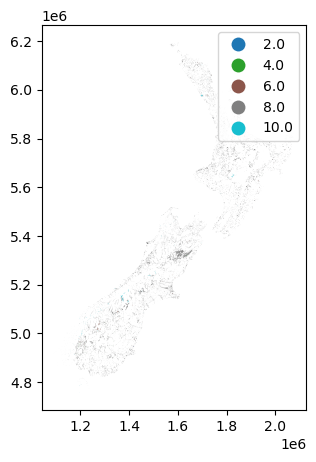

In [24]:
## PLOT
fig, ax = plt.subplots(figsize=(12,5))
final.plot(column='PixelScore', ax=ax, legend=True, categorical=True)
plt.show()

## Save file

In [29]:
final['PrioOption'] = final['Attribute'].copy() 
final['Area_ha'] = final.area * m2_to_ha
final = final[final.Area_ha > small_polygon_threshold].copy().reset_index(drop=True)
final['Area_ha'] = final['Area_ha'].round(2)
final[keep_cols_catch].to_file('../OutputArtifacts/A04_LegalProtection/A04_LegalProtection_20240829.gpkg')

In [33]:
for n_catch, catch in enumerate(aoi.Catchment.sort_values().unique()):
    start_time = time.time()
    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))
    print(f"\n{n_catch}_{catch.upper()}      {current_time}")

    ## Filter to each catchment
    sub_final = final[final['Catchment'] == catch][keep_cols_catch].reset_index(drop=True)

    if sub_final.shape[0] > 0:
        base_path = r'..\OutputArtifacts\A04_LegalProtection\A04_Catchments'
        sub_final.to_file(f"{base_path}\{str(n_catch).zfill(3)}_{catch}_LegalProtection_20240829.gpkg")


0_APARIMA      2024-09-08 13:17:06

1_ASHBURTON-HINDS      2024-09-08 13:17:06

2_AUCKLAND BASIN      2024-09-08 13:17:06

3_AUCKLAND OFFSHORE ISLANDS      2024-09-08 13:17:06

4_AWATERE      2024-09-08 13:17:06

5_BANKS PENINSULA      2024-09-08 13:17:06

6_BAY OF PLENTY OFFSHORE ISLANDS      2024-09-08 13:17:06

7_BLUFF OFFSHORE      2024-09-08 13:17:06

8_BULLER      2024-09-08 13:17:06

9_CATLINS      2024-09-08 13:17:06

10_CLARENCE      2024-09-08 13:17:06

11_CLUTHA      2024-09-08 13:17:06

12_CONWAY      2024-09-08 13:17:06

13_COROMANDEL      2024-09-08 13:17:06

14_COROMANDEL OFFSHORE ISLANDS      2024-09-08 13:17:06

15_EAST-CAPE      2024-09-08 13:17:06

16_FAR NORTH      2024-09-08 13:17:06

17_FAR NORTH OFFSHORE ISLANDS      2024-09-08 13:17:06

18_FIORDLAND      2024-09-08 13:17:06

19_FOX-WHATAROA      2024-09-08 13:17:06

20_GOLDEN BAY      2024-09-08 13:17:06

21_GREAT BARRIER ISLANDS      2024-09-08 13:17:06

22_GREY      2024-09-08 13:17:06

23_HAAST      2024-09-